# Rapport analytique — Marché immobilier francilien (DVF)

Analyse par agrégations de la base `dvf` (départements 75, 92, 93).
Chaque agrégation répond à une question métier **et** défend une décision d'architecture.

> Avant de lancer : la base doit être chargée sur Atlas et le fichier `.env` rempli.
> `python -m src.load_data --csv data/full.csv.gz --departements 75 92 93`


In [2]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
from src.config import get_db
from src.aggregations import (
    prix_median_par_commune_trimestre,
    ecart_maison_appart_par_densite,
    part_volume_multilots,
)
db = get_db()
print("Connexion OK :", db.name)

Connexion OK : dvf


## Agrégation 1 — Prix médian au m² par commune et trimestre

**Question métier :** où et quand les prix montent-ils ou baissent-ils ?
**Défend :** l'exploitation de la dimension temporelle (`date_mutation`), qui a motivé le choix du dataset.
On prend la médiane et non la moyenne, car le prix immobilier a des valeurs extrêmes.

In [3]:
res1 = prix_median_par_commune_trimestre(db, limite=60)
df1 = pd.json_normalize(res1)
df1["periode"] = df1["_id.annee"].astype(str) + "-T" + df1["_id.trimestre"].astype(int).astype(str)
df1 = df1.rename(columns={"_id.commune": "commune"})
df1[["commune", "periode", "prix_m2_median", "nb_ventes"]].head(12)

,commune,periode,prix_m2_median,nb_ventes
0,Antony,2025-T1,5000.000000,133
1,Antony,2025-T2,5090.322581,129
2,Antony,2025-T3,5396.551724,143
3,Antony,2025-T4,4880.952381,117
4,Asnières-sur-Seine,2025-T1,6087.500000,296
5,Asnières-sur-Seine,2025-T2,6219.512195,291
6,Asnières-sur-Seine,2025-T3,6352.941176,344
7,Asnières-sur-Seine,2025-T4,6127.659574,306
8,Aubervilliers,2025-T1,4100.000000,130
9,Aubervilliers,2025-T2,3853.658537,153


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for commune, g in df1.groupby("commune"):
    g = g.sort_values("periode")
    ax.plot(g["periode"], g["prix_m2_median"], marker="o", label=commune)
ax.set_xlabel("Trimestre"); ax.set_ylabel("Prix médian au m² (€)")
ax.set_title("Évolution du prix médian au m² par commune")
ax.legend(fontsize=8, ncol=2); plt.xticks(rotation=45); plt.tight_layout()
plt.show()

## Agrégation 2 — Écart maison / appartement par département

**Question métier :** l'écart de prix entre maisons et appartements est-il le même partout ?
**Défend :** le `$lookup` vers la collection `communes` → justifie le **référencement** de la commune.
C'est l'agrégation à savoir expliquer à la volée jeudi.

In [5]:
res2 = ecart_maison_appart_par_densite(db)
df2 = pd.json_normalize(res2)
df2 = df2.rename(columns={"_id.dept": "dept", "_id.type": "type"})
pivot = df2.pivot_table(index="dept", columns="type", values="prix_m2_moyen")
pivot

type,Appartement,Maison
dept,,
75,66596.814234,24658.678413
92,51103.388338,14788.566140
93,166276.964251,14529.991289


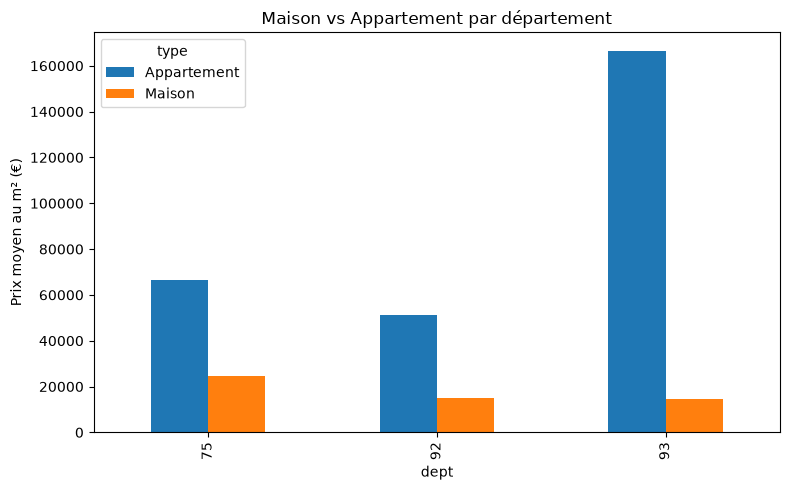

In [6]:
pivot.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Prix moyen au m² (€)"); plt.title("Maison vs Appartement par département")
plt.tight_layout(); plt.show()

## Agrégation 3 — Part du volume des ventes multi-lots

**Question métier :** les grosses ventes (nombreux lots) sont-elles marginales ou pèsent-elles lourd ?
**Défend :** l'usage de `$size` sur le tableau embarqué → justifie l'**embarquement** des lots.
On vérifie que la somme des parts fait bien 100 % (contrôle de cohérence).

In [7]:
res3 = part_volume_multilots(db)
df3 = pd.DataFrame(res3).sort_values("tranche")
libelles = {1: "1 lot", 2: "2-5 lots", 6: "6-20 lots", 21: "21+ lots"}
df3["libelle"] = df3["tranche"].map(lambda x: libelles.get(x, str(x)))
print("Somme des parts :", round(df3["part_volume_pct"].sum(), 2), "%  (doit valoir ~100)")
df3[["libelle", "nb_mutations", "valeur_totale", "part_volume_pct"]]

Somme des parts : 100.0 %  (doit valoir ~100)


,libelle,nb_mutations,valeur_totale,part_volume_pct
0,1 lot,31808,1.254477e+10,24.148289
1,2-5 lots,51616,3.041834e+10,58.554345
2,6-20 lots,1024,4.729761e+09,9.104642
3,21+ lots,354,4.256030e+09,8.192724


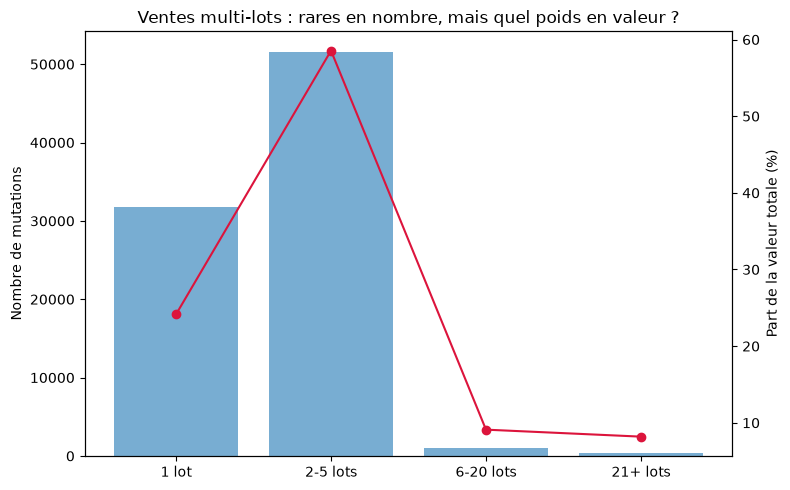

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(df3["libelle"], df3["nb_mutations"], alpha=0.6, label="Nb de mutations")
ax1.set_ylabel("Nombre de mutations")
ax2 = ax1.twinx()
ax2.plot(df3["libelle"], df3["part_volume_pct"], color="crimson", marker="o", label="% du volume €")
ax2.set_ylabel("Part de la valeur totale (%)")
plt.title("Ventes multi-lots : rares en nombre, mais quel poids en valeur ?")
plt.tight_layout(); plt.show()

## Conclusion

Les trois agrégations forment un ensemble cohérent : chacune éclaire une décision d'architecture.
La #1 exploite le temporel, la #2 justifie le référencement de la commune, la #3 justifie
l'embarquement des lots. C'est cette lecture qui est défendue en soutenance.